In [1]:
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
import random
import matplotlib.pyplot as plt
from scipy.stats import skew
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split    
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from skimage import feature 
from torchvision import datasets, models, transforms
import pickle
import os

In [2]:
IMG_SIZE = (227, 227)
NUM_AUGMENTATIONS_PER_IMAGE = 3
# LABELS = np.array(['Bacterialblight', 'Blast', 'Brownspot', 'Healthy', 'Tungro'])
# LABELS = np.array(['Hispa', 'LeafBlast', 'BrownSpot', 'Healthy'])
dataset_path = 'datasets/local_dataset_no_duplicate'
# augmented_dataset_path = 'datasets/Mixed on field/augmented_images'
is_train_splitted = False
LABELS = np.array(os.listdir(f'{dataset_path}/train_images')) if is_train_splitted else np.array(os.listdir(dataset_path))
TRAIN_SPLIT_RATIO = 0.8
TEST_SPLIT_RATIO = 0.5

In [3]:
# Load data
def load_images_from_directory(base_path, limit=1000):
    data = []
    labels = []
    for folder_name in LABELS:
        data_length = len(data)
        folder_path = os.path.join(base_path, folder_name)
        if not os.path.exists(folder_path):
            print(f"Directory not found: {folder_path}")
            continue
        
        print(len(os.listdir(folder_path)), "images in", folder_name)
        for i, filename in enumerate(os.listdir(folder_path)):
            if i == limit: break
            image_path = os.path.join(folder_path, filename)
            img = cv2.imread(image_path)
            if img is None:
                print(f"Failed to load image: {image_path}")
                continue

            data.append(cv2.resize(img, IMG_SIZE))
            labels.append(folder_name)
        print(f"Loaded {len(data)-data_length} images from {folder_name}")
    print('dataset loaded')
    print('dataset len:', len(data))
    print('labels len:', len(labels))
    return np.array(data), np.array(labels)


In [4]:
dataset, labels = load_images_from_directory(dataset_path, 960)

1326 images in bacterial_leaf_blight
Loaded 960 images from bacterial_leaf_blight
960 images in blast
Loaded 960 images from blast
1200 images in brown_spot
Loaded 960 images from brown_spot
1488 images in normal
Loaded 960 images from normal
1308 images in tungro
Loaded 960 images from tungro
dataset loaded
dataset len: 4800
labels len: 4800


In [5]:
extra_dataset1, extra_labels1 = load_images_from_directory('datasets/paddy-disease-classification/train_images', 1700)
extra_dataset2, extra_labels2 = load_images_from_directory('datasets/rice_leaves_disease', 180)

dataset = np.concatenate((dataset, extra_dataset1), axis=0)
labels = np.concatenate((labels, extra_labels1), axis=0)

dataset = np.concatenate((dataset, extra_dataset2), axis=0)
labels = np.concatenate((labels, extra_labels2), axis=0)

print('extra dataset loaded')
print('dataset shape:', dataset.shape)
print('labels shape:', labels.shape)

479 images in bacterial_leaf_blight
Loaded 479 images from bacterial_leaf_blight
1738 images in blast
Loaded 1700 images from blast
965 images in brown_spot
Loaded 965 images from brown_spot
1764 images in normal
Loaded 1700 images from normal
1088 images in tungro
Loaded 1088 images from tungro
dataset loaded
dataset len: 5932
labels len: 5932
180 images in bacterial_leaf_blight
Loaded 180 images from bacterial_leaf_blight
305 images in blast
Loaded 180 images from blast
267 images in brown_spot
Loaded 180 images from brown_spot
157 images in normal
Loaded 157 images from normal
Directory not found: datasets/rice_leaves_disease\tungro
dataset loaded
dataset len: 697
labels len: 697
extra dataset loaded
dataset shape: (11429, 227, 227, 3)
labels shape: (11429,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(dataset, labels, train_size=TRAIN_SPLIT_RATIO, random_state=42)
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, train_size=TEST_SPLIT_RATIO, random_state=42)

In [9]:
# Save test data from splitted dataset
def save_test_data(X, y, output_dir):
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    
    for i, (image, label) in enumerate(zip(X, y)):
        if not os.path.exists(f"{output_dir}/{label}"):
            os.makedirs(f"{output_dir}/{label}")
        image_path = os.path.join(output_dir, f"{label}/{label}_{i}.jpg")
        cv2.imwrite(image_path, image)
        
save_test_data(X_test, y_test, 'datasets/result/test_images')

In [ ]:
# X_train, y_train = load_images_from_directory(f'{dataset_path}/train_images/', LIMIT)
# X_test, y_test = load_images_from_directory(f'{dataset_path}/test_images/', LIMIT)
# X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, train_size=TEST_SPLIT_RATIO, random_state=42)

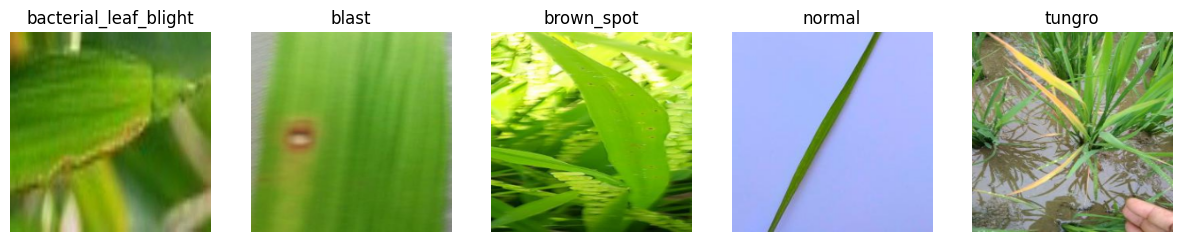

In [14]:
if len(LABELS) < 5: cols = len(LABELS)
else: cols = 5
row = (len(LABELS) // 5)+1

fig = plt.figure(figsize=(15, 6))
for j in range(len(LABELS)):
    fig.add_subplot(row, cols, j+1)
    index = np.where(labels == LABELS[j])[0][0]
    plt.imshow(cv2.cvtColor(dataset[index], cv2.COLOR_BGR2RGB))
    plt.axis('off') 
    plt.title(LABELS[j])

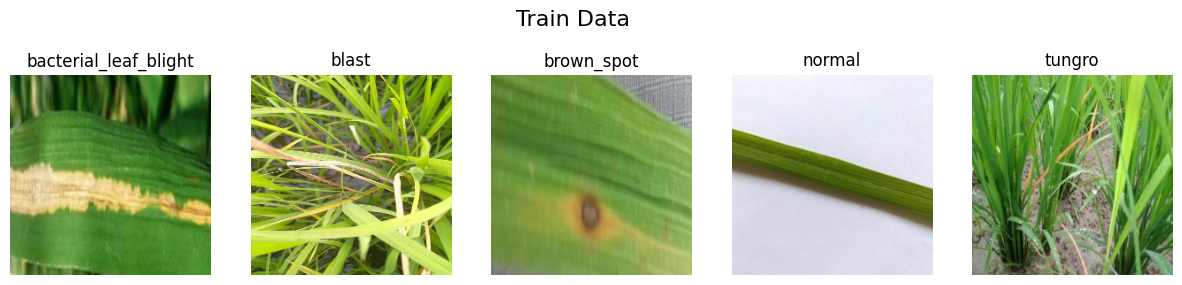

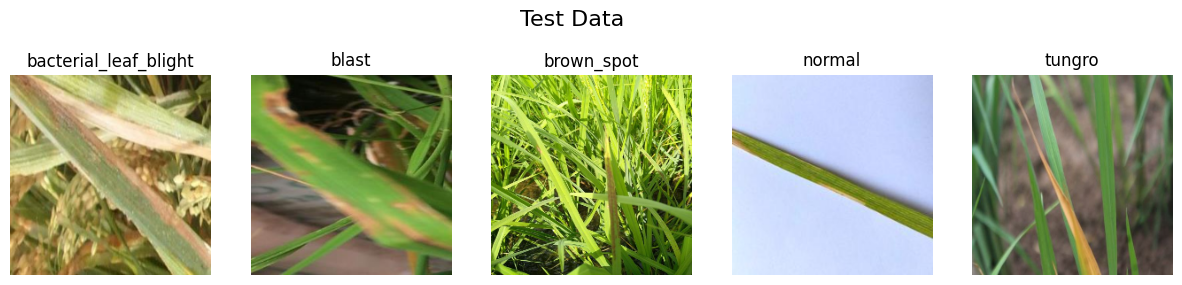

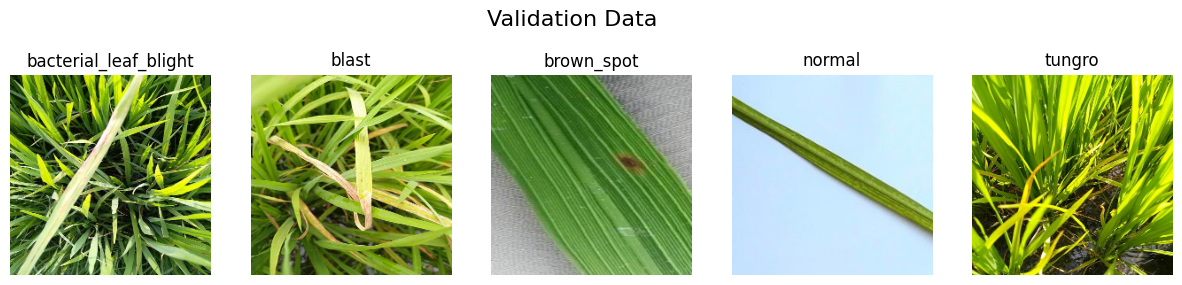

In [ ]:
fig = plt.figure(figsize=(15, 6))

fig.suptitle('Train Data', fontsize=16)

if len(LABELS) < 5: cols = len(LABELS)
else: cols = 5

row = (len(LABELS) // 5)+1

for j in range(len(LABELS)):
    fig.add_subplot(row, cols, j+1)
    index = np.where(y_train == LABELS[j])[0][0]
    plt.imshow(cv2.cvtColor(X_train[index], cv2.COLOR_BGR2RGB))
    plt.axis('off') 
    plt.title(LABELS[j])


fig = plt.figure(figsize=(15, 6))

fig.suptitle('Test Data', fontsize=16)

for j in range(len(LABELS)):
    fig.add_subplot(row, cols, j+1)
    index = np.where(y_test == LABELS[j])[0][0]
    plt.imshow(cv2.cvtColor(X_test[index], cv2.COLOR_BGR2RGB))
    plt.axis('off') 
    plt.title(LABELS[j])
    
fig = plt.figure(figsize=(15, 6))

fig.suptitle('Validation Data', fontsize=16)

for j in range(len(LABELS)):
    fig.add_subplot(row, cols, j+1)
    index = np.where(y_val == LABELS[j])[0][0]
    plt.imshow(cv2.cvtColor(X_val[index], cv2.COLOR_BGR2RGB))
    plt.axis('off') 
    plt.title(LABELS[j])

# Pre-Processing


In [55]:
def normalize_image(image):
    nmax = 255 #New maximum
    nmin = 0 #New minimum
    return cv2.normalize(image,None,alpha = nmin,beta = nmax,norm_type = cv2.NORM_MINMAX)

In [12]:
def rotate_image(image, angle):
    (h, w) = image.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    # Menggunakan BORDER_REPLICATE untuk mengisi piksel kosong dengan piksel tepi terdekat
    rotated = cv2.warpAffine(image, M, (w, h), borderMode=cv2.BORDER_REPLICATE)
    return rotated

In [13]:
def flip_horizontal(image):
    return cv2.flip(image, 1)

In [14]:
def translate_image(image, dx, dy):
    (h, w) = image.shape[:2]
    M = np.float32([[1, 0, dx], [0, 1, dy]])
    translated = cv2.warpAffine(image, M, (w, h), borderMode=cv2.BORDER_REPLICATE)
    return translated

In [15]:
def zoom_image(image, zoom_factor):
    # Resize gambar sesuai faktor zoom
    resized = cv2.resize(image, None, fx=zoom_factor, fy=zoom_factor, interpolation=cv2.INTER_LINEAR)

    # Jika hasil zoom lebih besar dari IMG_SIZE, crop bagian tengah
    if resized.shape[0] > IMG_SIZE[0] or resized.shape[1] > IMG_SIZE[1]:
        start_row = (resized.shape[0] - IMG_SIZE[0]) // 2
        end_row = start_row + IMG_SIZE[0]
        start_col = (resized.shape[1] - IMG_SIZE[1]) // 2
        end_col = start_col + IMG_SIZE[1]
        cropped = resized[start_row:end_row, start_col:end_col]
        return cropped
    # Jika hasil zoom lebih kecil, tambahkan padding (ini yang menghasilkan piksel kosong)
    else:
        top = (IMG_SIZE[0] - resized.shape[0]) // 2
        bottom = IMG_SIZE[0] - resized.shape[0] - top
        left = (IMG_SIZE[1] - resized.shape[1]) // 2
        right = IMG_SIZE[1] - resized.shape[1] - left
        # Mengisi dengan piksel tepi terdekat
        padded = cv2.copyMakeBorder(resized, top, bottom, left, right, borderType=cv2.BORDER_REPLICATE)
        return padded

In [16]:
def adjust_brightness(image, value=30):
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(hsv)
    v = cv2.add(v, value) # Tambah nilai untuk mencerahkan
    v[v > 255] = 255 # Batasi nilai maksimum
    v[v < 0] = 0   # Batasi nilai minimum
    final_hsv = cv2.merge([h, s, v])
    brightened = cv2.cvtColor(final_hsv, cv2.COLOR_HSV2BGR)
    return brightened

In [17]:
def adjust_contrast(image, alpha=1.2): # alpha > 1 untuk meningkatkan kontras, < 1 untuk menurunkan
    return cv2.convertScaleAbs(image, alpha=alpha, beta=0)
    # alpha: faktor kontras (skala), beta: faktor kecerahan (shift)

In [18]:
def adjust_saturation(image, factor=1.2): # factor > 1 untuk meningkatkan, < 1 untuk menurunkan
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(hsv)
    s = cv2.multiply(s, factor)
    s[s > 255] = 255
    s[s < 0] = 0
    final_hsv = cv2.merge([h, s, v])
    saturated = cv2.cvtColor(final_hsv, cv2.COLOR_HSV2BGR)
    return saturated

In [19]:
def add_gaussian_noise(image, mean=0, var=0.01):
    image_float = image.astype(np.float32) / 255.0 # Normalisasi ke 0-1
    sigma = var**0.5
    gauss = np.random.normal(mean, sigma, image_float.shape)
    noisy_image = image_float + gauss
    noisy_image = np.clip(noisy_image, 0, 1) # Pastikan rentang 0-1
    noisy_image = (noisy_image * 255).astype(np.uint8)
    return noisy_image

In [20]:
def augment_images(X, y):
    for i, img in enumerate(X):
        for _ in range(NUM_AUGMENTATIONS_PER_IMAGE):
            augmented_img = img.copy() # Mulai dari salinan gambar asli

            # Terapkan augmentasi secara acak
            if random.random() < 0.7: # 70% kemungkinan rotasi
                augmented_img = rotate_image(augmented_img, random.uniform(-15, 15))
            if random.random() < 0.5: # 50% kemungkinan flip horizontal
                augmented_img = flip_horizontal(augmented_img)
            if random.random() < 0.6: # 60% kemungkinan geser
                dx = random.randint(-20, 20)
                dy = random.randint(-20, 20)
                augmented_img = translate_image(augmented_img, dx, dy)
            if random.random() < 0.4: # 40% kemungkinan perubahan kecerahan
                augmented_img = adjust_brightness(augmented_img, random.randint(-50, 50))
            if random.random() < 0.4: # 40% kemungkinan perubahan kontras
                augmented_img = adjust_contrast(augmented_img, random.uniform(0.7, 1.3))
            if random.random() < 0.3: # 30% kemungkinan tambah noise
                augmented_img = add_gaussian_noise(augmented_img, var=random.uniform(0.005, 0.02))
            # Tambahkan augmentasi lain sesuai kebutuhan
            
            write_path = f"{augmented_dataset_path}/{y[i]}/"
            os.makedirs(f'{write_path}', exist_ok=True)
            cv2.imwrite(f"{write_path}/augmented_image_{i}_{_}.jpg", augmented_img)

In [ ]:
# augment_images(X_train, y_train)

In [ ]:
# augmented_X_train, augmented_y_train = load_images_from_directory(augmented_dataset_path, LIMIT)

# X_train = np.append(X_train, augmented_X_train, axis=0)
# y_train = np.append(y_train, augmented_y_train)

1113 images in bacterial_leaf_blight
Loaded 1113 images from bacterial_leaf_blight
3105 images in blast
Loaded 2413 images from blast
2376 images in brown_spot
Loaded 3713 images from brown_spot
3123 images in normal
Loaded 5013 images from normal
2598 images in tungro
Loaded 6313 images from tungro


In [ ]:
# print(f"Total training images after augmentation: {len(X_train)}")

Total training images after augmentation: 6400


In [87]:
# def segment_image(image, label):
def segment_image(image):
    hsv_img = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    
    # fig = plt.figure(figsize=(9, 6))

    # plt.axis('off') 
    # plt.title(label)
    # plt.imshow(cv2.cvtColor(mask2*255, cv2.COLOR_BGR2RGB))
    
    lower_yellow = np.array([ 15, 0, 56])  # Adjust as needed
    upper_yellow = np.array([32, 255, 255])  # Adjust as
    
    lower_chocolate = np.array([0, 10, 0])
    upper_chocolate = np.array([15, 255, 255])
    
    yellow_mask = cv2.inRange(hsv_img, lower_yellow, upper_yellow)
    dark_chocolate_mask = cv2.inRange(hsv_img, lower_chocolate, upper_chocolate)
    
    mask3 = cv2.bitwise_or(yellow_mask, dark_chocolate_mask)
    mask3 = cv2.dilate(mask3, None, iterations=1)
    mask3 = cv2.erode(mask3, None, iterations=1)
    result = cv2.bitwise_and(image, image, mask=mask3)
    
    # mask = np.zeros(image.shape[:2], np.uint8)
    # bgModel = np.zeros((1, 65), np.float64)
    # fgModel = np.zeros((1, 65), np.float64)

    # # Rectangle awal perkiraan daun
    # rect = (1, 1, 225, 225)
    # cv2.grabCut(image, mask, rect, bgModel, fgModel, 8, cv2.GC_INIT_WITH_RECT)

    # mask2 = np.where((mask == 2) | (mask == 0), 0, 1).astype("uint8")
    # result = cv2.bitwise_and(result, result, mask=mask2)
    
    # print(mask3.max(), image.shape)
    
    # fig = plt.figure(figsize=(9, 6))

    # plt.axis('off') 
    # plt.title(label)
    # plt.imshow(cv2.cvtColor(mask3, cv2.COLOR_BGR2RGB))
    
    return result
    # return mask

Text(0.5, 1.0, 'tungro')

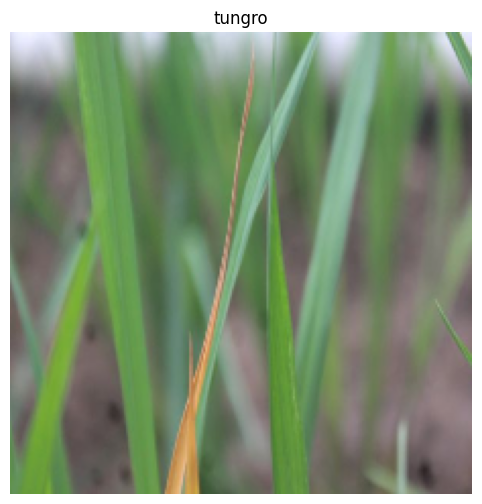

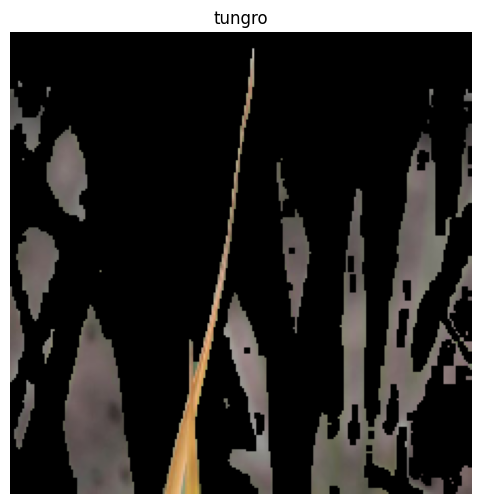

In [88]:
segementation_test = segment_image(X_train[0])

fig = plt.figure(figsize=(9, 6))

plt.imshow(cv2.cvtColor(X_train[0], cv2.COLOR_BGR2RGB))
plt.axis('off') 
plt.title(y_train[0])

fig = plt.figure(figsize=(9, 6))

plt.imshow(cv2.cvtColor(segementation_test, cv2.COLOR_BGR2RGB))
plt.axis('off') 
plt.title(y_train[0])

In [ ]:
def calculate_color_moments(image):
    moments = []
    
    b, g, r = cv2.split(image)
    for channel in [b, g, r]:
        # print(cv2.moments(channel).values())
        moments.extend(cv2.moments(channel).values())
        # moments.extend([mean, variance])
    return np.array(moments)

In [11]:
def calculate_texture_features_n_hog(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    glcm = feature.graycomatrix(gray, distances=[1], angles=[0], symmetric=True, normed=True)
    contrast = feature.graycoprops(glcm, 'contrast')
    energy = feature.graycoprops(glcm, 'energy')
    homogeneity = feature.graycoprops(glcm, 'homogeneity')
    correlation = feature.graycoprops(glcm, 'correlation')
    dissimilarity = feature.graycoprops(glcm, 'dissimilarity')
    
    # lbp = feature.local_binary_pattern(gray, P=8, R=1, method='uniform')
    hog = feature.hog(gray, pixels_per_cell=(30, 30), cells_per_block=(1, 1), visualize=False, feature_vector=True)
    # return hog
    # return np.concatenate((lbp.flatten(), hog))
    print(len(np.concatenate((contrast.flatten(), energy.flatten(), homogeneity.flatten(), correlation.flatten(), dissimilarity.flatten()))))
    print(len(hog))
    return np.concatenate((hog,contrast.flatten(), energy.flatten(), homogeneity.flatten(), correlation.flatten(), dissimilarity.flatten()))
    # return np.concatenate((contrast.flatten(), energy.flatten(), homogeneity.flatten(), correlation.flatten(), dissimilarity.flatten()))
    # return np.concatenate((hog,glcm.flatten()))

In [8]:
def calculate_histogram(image, channels, mask=None, histSize=[256], ranges=[0, 256]):
    result = []
    for i in range(len(channels)):
        hist = cv2.calcHist([image], [i], mask, histSize, ranges)
        cv2.normalize(hist, hist)
        hist.flatten()
        result.append(hist)
    print(len(np.array(result).flatten()))
    return np.array(result).flatten()

In [9]:
def extract_features(images):
    features = []
    for img in images:
        # normalized = normalize_image(img)
        # segmented = segment_image(normalized)
        # segmented = segment_image(img)
        # normalized_255 = np.clip(normalized * 255, 0, 255).astype(np.uint8)
        # fig = plt.figure(figsize=(9, 6))

        # plt.imshow(cv2.cvtColor(normalized_255, cv2.COLOR_BGR2RGB))
        # plt.axis('off') 
        # plt.title(LABELS[j])
        # color_hist_hsv = calculate_histogram(cv2.cvtColor(normalized, cv2.COLOR_BGR2HSV), channels=[0, 1, 2])
        color_hist_hsv = calculate_histogram(cv2.cvtColor(img, cv2.COLOR_BGR2HSV), channels=[0, 1, 2])
        # color_hist_rgb = calculate_histogram(segmented, channels=[0, 1, 2])
        # color_moments = calculate_color_moments(segmented)
        # hu_moments = cv2.HuMoments(cv2.moments(cv2.cvtColor(segmented, cv2.COLOR_BGR2GRAY))).flatten()
        texture_features_n_hog = calculate_texture_features_n_hog(img)
        # feature_vector = np.concatenate((color_hist, color_moments, texture_features_n_hog))
        # feature_vector = np.concatenate((color_hist, color_moments, hu_moments))
        # feature_vector = np.concatenate((color_hist_hsv, color_hist_rgb, hu_moments, texture_features_n_hog))
        # feature_vector = np.concatenate((color_hist_hsv, hu_moments, texture_features_n_hog))
        # feature_vector = np.concatenate((color_hist_hsv, hu_moments))
        # feature_vector = np.concatenate((hu_moments, texture_features_n_hog))
        feature_vector = np.concatenate((color_hist_hsv, texture_features_n_hog)) # hog 76% accuracy | glcm 72% accuracy | hog & glcm 78% accuracy
        features.append(feature_vector)
        # features.append(color_hist_hsv) #72%
        # features.append(hu_moments) #36%
        # features.append(texture_features_n_hog) #59% hog | 43% texture
    return np.array(features)

In [12]:
feature_img1 = extract_features([X_train[0]])
print(feature_img1.shape)

768
5
441
(1, 1214)


In [127]:
X_train_features = extract_features(X_train)
# X_test_features = extract_features(X_test)
X_val_features = extract_features(X_val)

In [128]:
scaler = StandardScaler()
x_train_normal = scaler.fit_transform(X_train_features)
x_val_normal = scaler.transform(X_val_features)

['bacterial_leaf_blight' 'blast' 'brown_spot' 'normal' 'tungro'] ['red', 'green', 'blue', 'yellow', 'gray']


C:\Users\RYZEN 5\AppData\Local\Temp\ipykernel_8600\12870594.py:11: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_color, cmap='viridis', alpha=0.8)


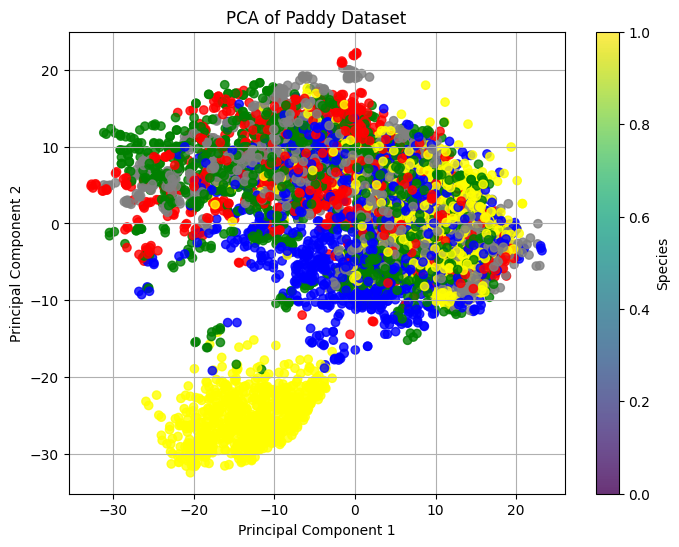

In [129]:
my_pca = PCA(n_components=2)
X_pca = my_pca.fit_transform(x_train_normal)

colors = ['red', 'green', 'blue', 'yellow', 'gray']

print(LABELS, colors)

y_color = [colors[np.where(LABELS == label)[0][0]] for label in y_train]

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_color, cmap='viridis', alpha=0.8)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Paddy Dataset')
plt.colorbar(label='Species')
plt.grid(True)
plt.show()

In [130]:
svm = SVC(kernel='rbf', C=100.0, gamma=0.001)
svm.fit(x_train_normal, y_train)

,C,100.0
,kernel,'rbf'
,degree,3
,gamma,0.001
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


                       precision    recall  f1-score   support

bacterial_leaf_blight       0.95      0.95      0.95       139
                blast       0.94      0.98      0.96       297
           brown_spot       0.96      0.96      0.96       200
               normal       0.97      0.95      0.96       284
               tungro       0.99      0.95      0.97       223

             accuracy                           0.96      1143
            macro avg       0.96      0.96      0.96      1143
         weighted avg       0.96      0.96      0.96      1143

Confusion Matrix for SVM:


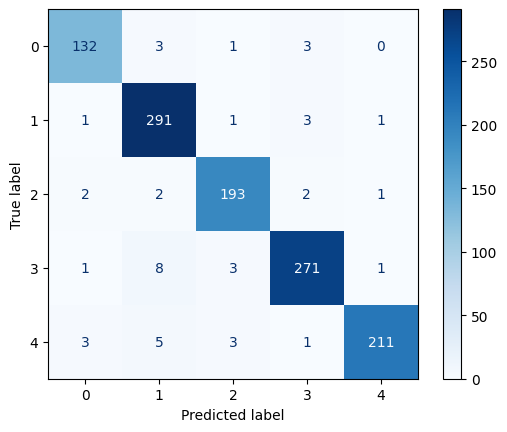

In [131]:
y_pred = svm.predict(x_val_normal)
print(classification_report(y_val, y_pred))
cm = confusion_matrix(y_val, y_pred)
print(f"Confusion Matrix for SVM:")
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
print("="*50)

In [24]:
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1e-3, 1e-2, 0.1, 1],
    'kernel': ['rbf']
}
grid_svm = GridSearchCV(SVC(), param_grid, cv=5)
grid_svm.fit(x_train_normal, y_train)

print("Best params:", grid_svm.best_params_)
print("Best score:", grid_svm.best_score_)

KeyboardInterrupt: 

In [250]:
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=5)
grid_rf.fit(x_train_normal, y_train)

print("Best RF Params:", grid_rf.best_params_)
print("Best RF Score:", grid_rf.best_score_)

Best RF Params: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 300}
Best RF Score: 0.9256027495775481


In [251]:
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs']
}

grid_lr = GridSearchCV(LogisticRegression(max_iter=1000), param_grid_lr, cv=5)
grid_lr.fit(x_train_normal, y_train)

print("Best LR Params:", grid_lr.best_params_)
print("Best LR Score:", grid_lr.best_score_)

c:\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1288: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
c:\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1288: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
c:\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1288: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in

Best LR Params: {'C': 0.1, 'solver': 'liblinear'}
Best LR Score: 0.7819849726233493


In [252]:
voting_clf = VotingClassifier(estimators=[
    ('svm', grid_svm.best_estimator_),
    ('rf', grid_rf.best_estimator_),
    ('lr', grid_lr.best_estimator_)
], voting='soft')

voting_clf.fit(x_train_normal, y_train)

c:\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1288: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


,estimators,"[('svm', ...), ('rf', ...), ...]"
,voting,'soft'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,C,100
,kernel,'rbf'
,degree,3
,gamma,0.001
,coef0,0.0


Evaluation for SVM:
                       precision    recall  f1-score   support

bacterial_leaf_blight       0.95      0.97      0.96       188
                blast       0.94      0.96      0.95       181
           brown_spot       0.97      0.96      0.97       194
               normal       0.95      0.94      0.95       203
               tungro       0.98      0.97      0.97       175

             accuracy                           0.96       941
            macro avg       0.96      0.96      0.96       941
         weighted avg       0.96      0.96      0.96       941

Confusion Matrix for SVM:
Evaluation for RF:
                       precision    recall  f1-score   support

bacterial_leaf_blight       0.98      0.95      0.96       188
                blast       0.89      0.95      0.92       181
           brown_spot       0.94      0.92      0.93       194
               normal       0.93      0.93      0.93       203
               tungro       0.95      0.95      0

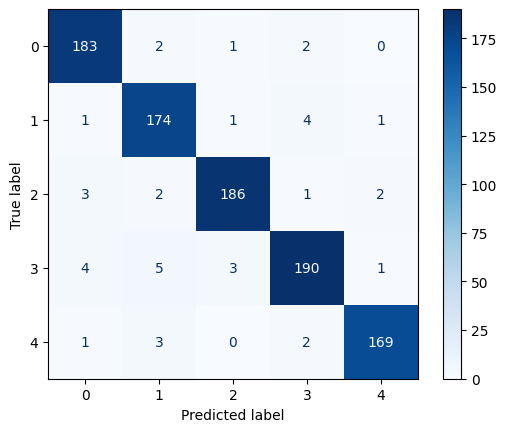

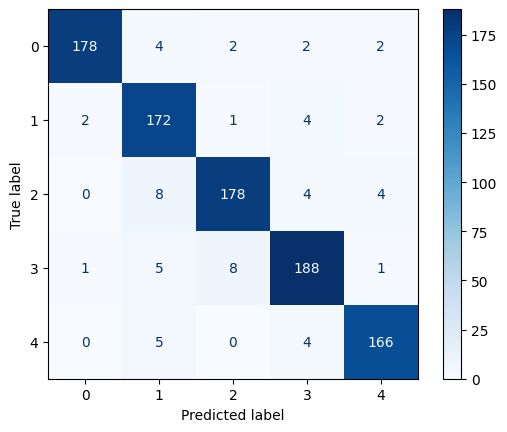

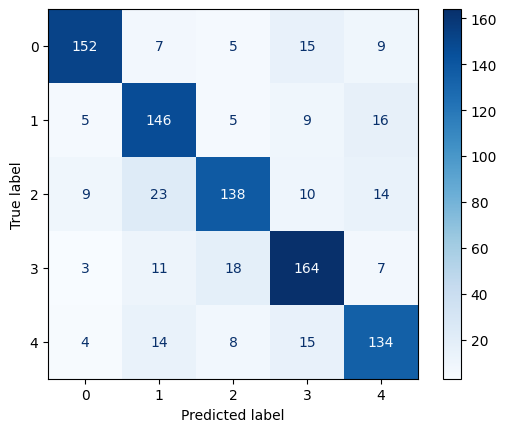

In [ ]:
models = voting_clf.named_estimators_
label_mapping = voting_clf.classes_

for name, model in models.items():
    y_pred = model.predict(x_val_normal)
    y_pred_str = [label_mapping[i] for i in y_pred]
    print(f"Evaluation for {name.upper()}:")
    print(classification_report(y_val, y_pred_str))
    cm = confusion_matrix(y_val, y_pred_str)
    print(f"Confusion Matrix for {name.upper()}:")
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    print("="*50)

In [254]:
# Save the model to disk
with open(os.path.join(f"E:/Backup Mario/Coding Room/Rice_Disease/Results/250704 1911 Mixed On Field", 'scaler.pkl'), 'wb') as file:
    pickle.dump(scaler, file)
    
with open(os.path.join(f"E:/Backup Mario/Coding Room/Rice_Disease/Results/250704 1911 Mixed On Field", 'svm.pkl'), 'wb') as file:
    pickle.dump(grid_svm, file)

with open(os.path.join(f"E:/Backup Mario/Coding Room/Rice_Disease/Results/250704 1911 Mixed On Field", 'rf.pkl'), 'wb') as file:
    pickle.dump(grid_rf, file)

with open(os.path.join(f"E:/Backup Mario/Coding Room/Rice_Disease/Results/250704 1911 Mixed On Field", 'lr.pkl'), 'wb') as file:
    pickle.dump(grid_lr, file)

In [ ]:
# Load the model from disk
with open('svm_1.pkl', 'rb') as file:
  loaded_classifier = pickle.load(file) 

# Use the loaded model to make predictions on new data
x_test_normal = scaler.transform(X_test_features)
predictions = svm.predict(x_test_normal)

In [ ]:
# Evaluate the model
test_accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy: {test_accuracy * 100:.4f}%")
test_precision, test_recall, test_fscore, test_average = precision_recall_fscore_support(y_test, predictions, average='weighted')
print(f"Precission: {test_precision * 100:.4f}%")
print(f"Recall: {test_recall * 100:.4f}%")
print(f"F1: {test_fscore * 100:.4f}%")

In [ ]:
cm = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.show()

In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_features, y_train)
y_pred_rf = rf.predict(X_val_features)

In [ ]:
# Evaluate the model
accuracy_rf = accuracy_score(y_val, y_pred_rf)
print(f"Accuracy: {accuracy_rf * 100:.4f}%")
precision_rf, recall_rf, fscore_rf, average_rf = precision_recall_fscore_support(y_val, y_pred_rf, average='weighted')
print(f"Precission: {precision_rf * 100:.4f}%")
print(f"Recall: {recall_rf * 100:.4f}%")
print(f"F1: {fscore_rf * 100:.4f}%")

In [ ]:
cm = confusion_matrix(y_val, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.show()

In [ ]:
prediction_rf = rf.predict(x_test_normal)